In [52]:
# Build and visualize a decision tree without external data
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

#Step 1: Simulated dataset (small, hardcoded)
data = {
    "Country": ["Nepal", "Kenya", "Germany", "India", "Australia", "Brazil"],
    "%Renewable": [88, 65, 45, 25, 35, 80],
    "CO2_per_capita": [1.2, 1.8, 6.5, 1.9, 17.0, 2.1],
    "Apply_Policy": ["yes", "yes", "no", "yes", "no", "yes"]
}

df = pd.DataFrame(data)

In [53]:
#Step 2: Encode the label for modeling
df["Label"] = df["Apply_Policy"].map({"yes": 1, "no": 0}) #.map() function applies this transformation to each value

In [54]:
#Step 3: Define features and target
X = df[["%Renewable", "CO2_per_capita"]]
y = df["Label"]

In [55]:
#Step 4: Train the decision tree
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

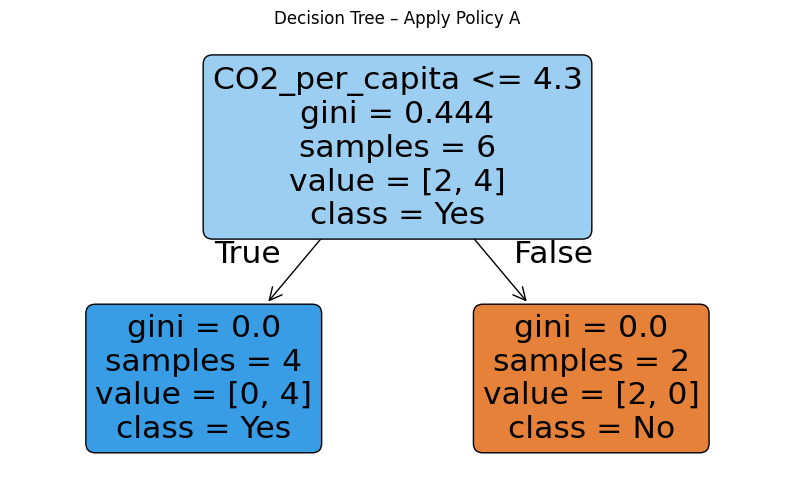

In [56]:
#Step 5: Visualise the tree
plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree – Apply Policy A")
plt.show()

In [57]:
df.head()

,Country,%Renewable,CO2_per_capita,Apply_Policy,Label
0,Nepal,88,1.2,yes,1
1,Kenya,65,1.8,yes,1
2,Germany,45,6.5,no,0
3,India,25,1.9,yes,1
4,Australia,35,17.0,no,0


In [59]:
df.loc[4, "CO2_per_capita"] = 1.5 #Changing value of CO2 emissions for Australia to 1.5
"""Classification of policy doesn't change"""

"Classification of policy doesn't change"

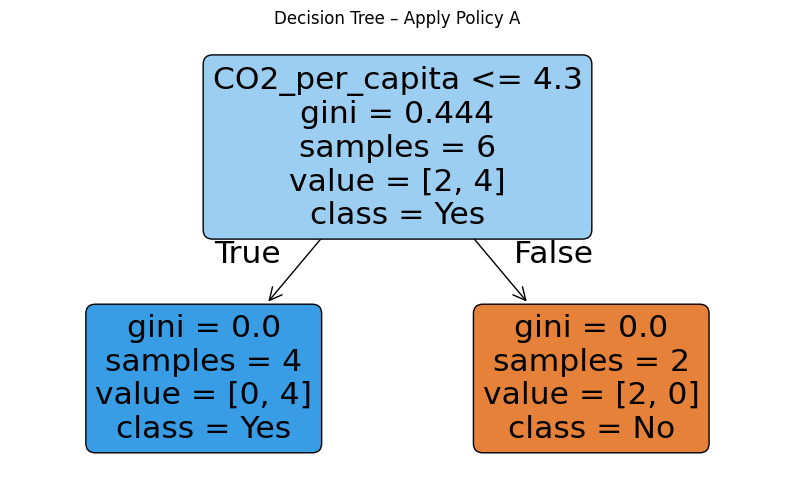

'Nothing has changed?'

In [60]:
tree = DecisionTreeClassifier(max_depth=2, random_state=0) #Changing max depth
tree.fit(X, y)
plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree – Apply Policy A")
plt.show()
"""Nothing has changed?"""


In [61]:
df

,Country,%Renewable,CO2_per_capita,Apply_Policy,Label
0,Nepal,88,1.2,yes,1
1,Kenya,65,1.8,yes,1
2,Germany,45,6.5,no,0
3,India,25,1.9,yes,1
4,Australia,35,1.5,no,0
5,Brazil,80,2.1,yes,1


In [62]:
df.loc[0, "Country"] = "Philippines"
df.loc[0, "%Renewable"] = 0
df.loc[0, "CO2_per_capita"] = 9.0
df

,Country,%Renewable,CO2_per_capita,Apply_Policy,Label
0,Philippines,0,9.0,yes,1
1,Kenya,65,1.8,yes,1
2,Germany,45,6.5,no,0
3,India,25,1.9,yes,1
4,Australia,35,1.5,no,0
5,Brazil,80,2.1,yes,1
